<a href="https://colab.research.google.com/github/xtianu/CV_Tirana_2026/blob/main/M3_Image%20Classification/Exercise3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MODULE 3: IMAGE CLASSIFICATION

Christian Mata, PhD

# **EXERCISE 3**

1. Load image

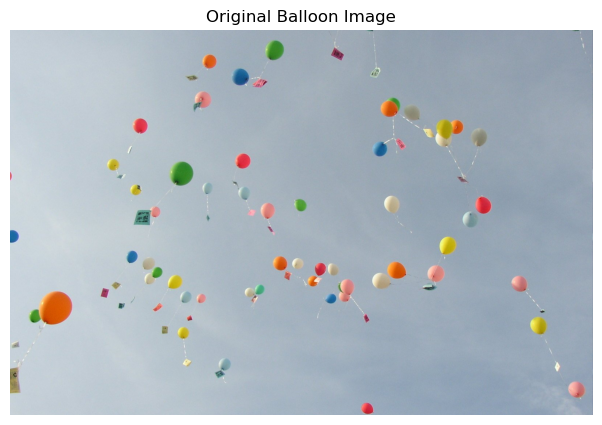

In [31]:
import skimage as sk
import matplotlib.pyplot as plt

path = 'images/baloons.jpg'
I = sk.io.imread(path)

plt.figure(figsize=(8, 5))
plt.imshow(I)
plt.title("Original Balloon Image")
plt.axis("off")
plt.show()


2.Convert from RGB to grayscale

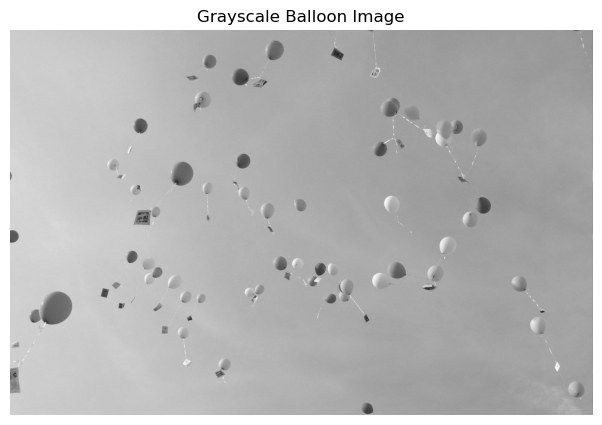

In [32]:
from skimage.color import rgb2gray 

I_gray = rgb2gray(I)
plt.figure(figsize=(8, 5))
plt.imshow(I_gray, cmap="gray")
plt.title("Grayscale Balloon Image")
plt.axis("off")
plt.show()

3. Gamma correction with $\gamma=0.5$

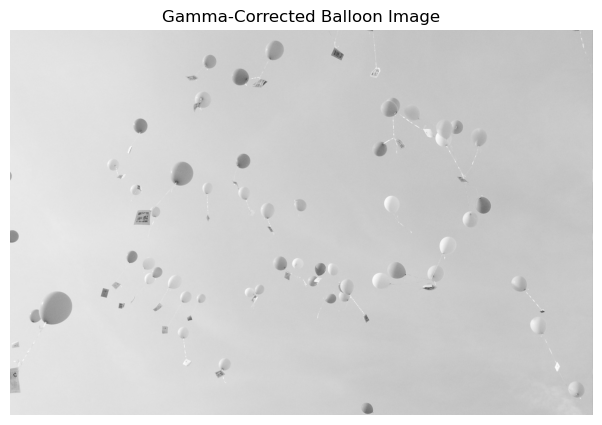

In [83]:
I_gamma = sk.exposure.adjust_gamma(I_gray, gamma=0.4)

plt.figure(figsize=(8, 5))
plt.imshow(I_gamma, cmap="gray")
plt.title("Gamma-Corrected Balloon Image")
plt.axis("off")
plt.show()


4. Otsu threshold from grayscale (non gamma corrected)

0.7109542057291668


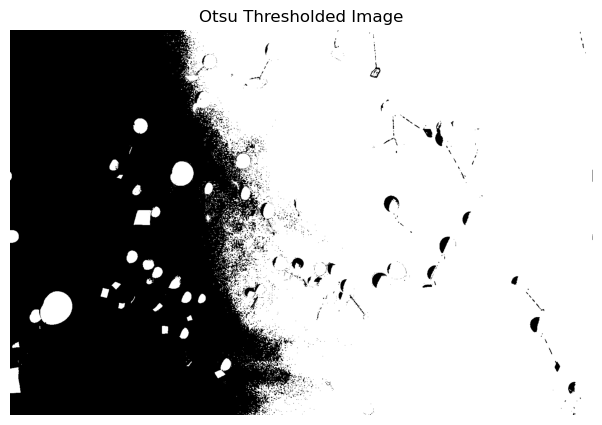

In [ ]:
from skimage.filters import threshold_otsu
thresh = threshold_otsu(I_gray)
print(thresh)
I_otsu = I_gamma < thresh

plt.figure(figsize=(8, 5))
plt.imshow(I_otsu, cmap="gray")
plt.title("Otsu Thresholded Image")
plt.axis("off")
plt.show()

5. Apply Otsu's threhold to gamma-corrected image

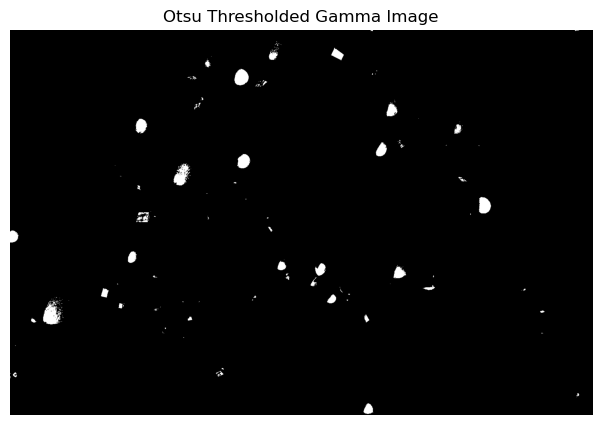

In [86]:
I_otsu_gamma = I_gamma < thresh

plt.figure(figsize=(8, 5))
plt.imshow(I_otsu_gamma, cmap="gray")
plt.title("Otsu Thresholded Gamma Image")
plt.axis("off")
plt.show()

6. label the objects

Number of regions: 235


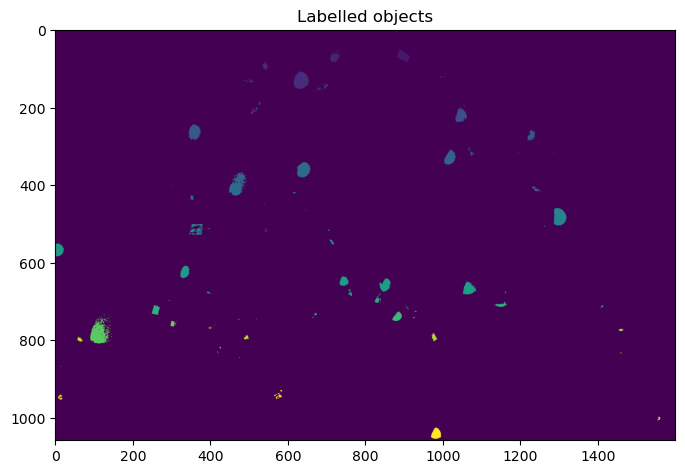

In [92]:
from skimage.measure import label
import matplotlib.pyplot as plt

label_image, nregions = label(I_otsu_gamma, return_num=True)

print(f"Number of regions: {nregions}")

plt.figure(figsize=(8, 6))
plt.imshow(label_image)
plt.title("Labelled objects")
plt.show()


7. Extract regional properties (Area and eccentricity)

In [97]:
from skimage.measure import regionprops
import pandas as pd

props = regionprops(label_image)

regions = []

for prop in props:
    regions.append({
        "label": prop.label,
        "area": prop.area,
        "eccentricity": prop.eccentricity
    })

regions_table = pd.DataFrame(regions)

regions_table.head()

,label,area,eccentricity
0,1,16.0,0.898357
1,2,11.0,0.909883
2,3,7.0,0.961409
3,4,2.0,1.000000
4,5,15.0,0.945176


Show the sccaterplot the features

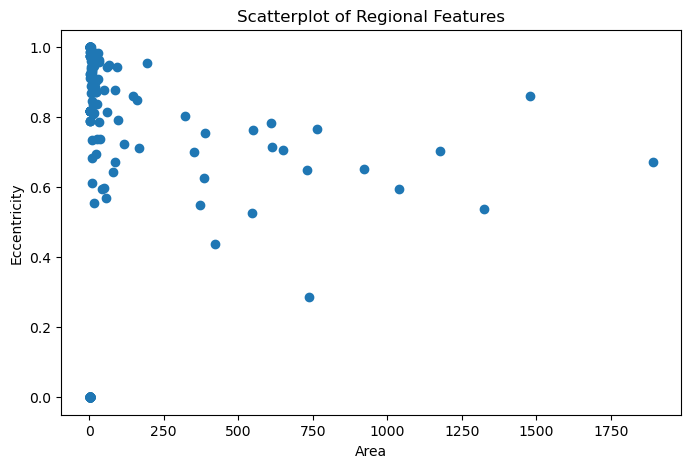

In [94]:
plt.figure(figsize=(8, 5))

plt.scatter(regions_table["area"], regions_table["eccentricity"])

plt.xlabel("Area")
plt.ylabel("Eccentricity")
plt.title("Scatterplot of Regional Features")

plt.show()

8. Find balloons as objects with area higher than 500 and eccentricity lower than 0.8


In [96]:
balloon_labels = []

for prop in props:
    if prop.area > 500 and prop.eccentricity < 0.8:
        balloon_labels.append(prop.label)

print(balloon_labels)

[15, 30, 57, 64, 75, 81, 107, 126, 127, 132, 134, 176, 235]


9. Plot the baloons

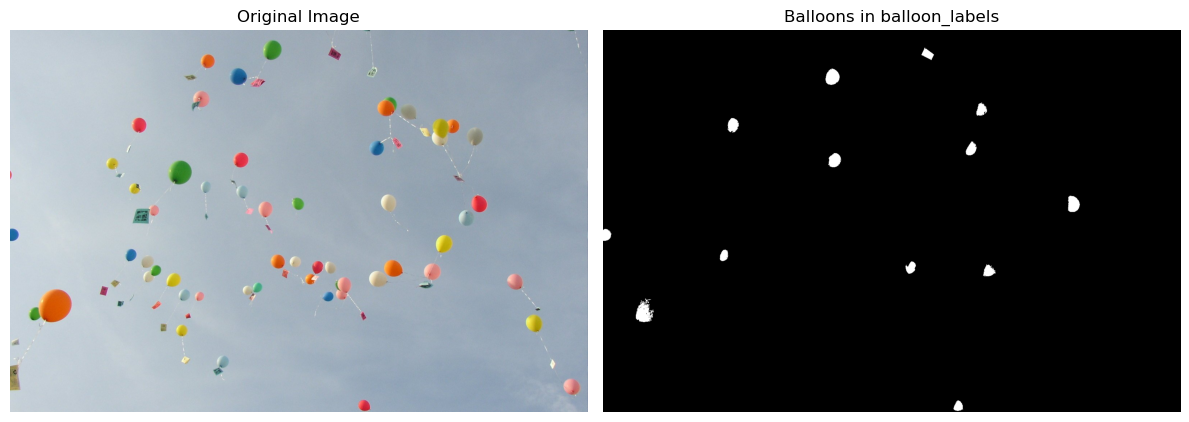

In [102]:
import numpy as np
import matplotlib.pyplot as plt

balloon_mask = np.zeros(label_image.shape, dtype=bool)

for lab in balloon_labels:
    balloon_mask[label_image == lab] = True

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].imshow(I)
ax[0].set_title("Original Image")
ax[0].axis("off")

ax[1].imshow(balloon_mask, cmap="gray")
ax[1].set_title("Balloons in balloon_labels")
ax[1].axis("off")

plt.tight_layout()
plt.show()